# EDA

## 1. Setup

In [57]:
import pandas as pd
from sqlalchemy import create_engine, types
from sqlalchemy import text # to be able to pass string
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### .env file

In [3]:
# Let's load values from the .env file
from dotenv import dotenv_values

config = dotenv_values()

# define variables for the login
pg_user = config['POSTGRES_USER']  # align the key label with your .env file !
pg_host = config['POSTGRES_HOST']
pg_port = config['POSTGRES_PORT']
pg_db = config['POSTGRES_DB']
pg_schema = config['POSTGRES_SCHEMA']
pg_pass = config['POSTGRES_PASS']

## 2. Reading in prep_tables

In [4]:
# Now building the URL with the values from the .env file

url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

# without specifying the schema default connection is to the schema `public`
# url = f'postgresql://{pg_user}:{pg_pass}@{pg_host}:{pg_port}/{pg_db}'

In [5]:
engine = create_engine(url, echo=False)

In [6]:
my_schema = 'crush' # update it to your schema

with engine.begin() as conn: 
    result = conn.execute(text(f'SET search_path TO {my_schema};'))

In [7]:
df_flights = pd.read_sql("SELECT * FROM prep_flights;", con=engine)
df_weather = pd.read_sql("SELECT * FROM prep_weather;", con=engine)


### Dataframes for prep_tables

In [8]:
df_flights

,flight_date,origin,dest,dep_time,arr_time,sched_dep_time,sched_arr_time,dep_delay,arr_delay,cancelled,diverted,distance_miles,distance_km,air_time_minutes
0,2003-02-01,LAS,PHL,36.0,823.0,44,815,-8.0,8.0,0,0,2176,3501.933627,252.0
1,2003-02-01,PHL,ATL,519.0,722.0,520,732,-1.0,-10.0,0,0,665,1070.214091,100.0
2,2003-02-01,BGR,LGA,535.0,713.0,530,710,5.0,3.0,0,0,378,608.332220,75.0
3,2003-02-01,BOS,PHL,532.0,655.0,530,654,2.0,1.0,0,0,280,450.616459,65.0
4,2003-02-01,MHT,PHL,527.0,648.0,530,658,-3.0,-10.0,0,0,290,466.709904,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63413,2003-02-28,PHX,PHL,2241.0,440.0,2245,510,-4.0,-30.0,0,0,2075,3339.389833,220.0
63414,2003-02-28,CVG,LGA,2249.0,34.0,2250,38,-1.0,-4.0,0,0,585,941.466531,75.0
63415,2003-02-28,LAS,IAD,2319.0,624.0,2315,635,4.0,-11.0,0,0,2066,3324.905733,220.0
63416,2003-02-28,OAK,IAD,2320.0,711.0,2320,715,0.0,-4.0,0,0,2409,3876.910895,270.0


In [9]:
df_weather

,airport_code,station_id,timestamp,temp_c,dewpoint_c,humidity_perc,precipitation_mm,snow_mm,wind_direction,wind_speed_kmh,...,date,time,hour,month_name,weekday,date_day,date_month,date_year,cw,day_part
0,BWI,72406,2003-02-07 00:00:00,0.0,-6.6,61.0,0.0,None,130.0,9.4,...,2003-02-07,00:00:00,00:00,february,friday,7.0,2.0,2003.0,6.0,night
1,BWI,72406,2003-02-07 01:00:00,-1.7,-2.8,92.0,NaN,None,170.0,7.6,...,2003-02-07,01:00:00,01:00,february,friday,7.0,2.0,2003.0,6.0,night
2,BWI,72406,2003-02-07 02:00:00,-1.7,-1.7,100.0,1.0,None,0.0,0.0,...,2003-02-07,02:00:00,02:00,february,friday,7.0,2.0,2003.0,6.0,night
3,BWI,72406,2003-02-07 03:00:00,-1.7,-1.7,100.0,1.5,None,0.0,0.0,...,2003-02-07,03:00:00,03:00,february,friday,7.0,2.0,2003.0,6.0,night
4,BWI,72406,2003-02-07 04:00:00,-1.7,-1.7,100.0,1.5,None,110.0,5.4,...,2003-02-07,04:00:00,04:00,february,friday,7.0,2.0,2003.0,6.0,night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1915,LGA,72503,2003-02-26 19:00:00,-7.2,-14.9,54.0,0.0,None,50.0,18.7,...,2003-02-26,19:00:00,19:00,february,wednesday,26.0,2.0,2003.0,9.0,evening
1916,LGA,72503,2003-02-26 20:00:00,-6.1,-13.9,54.0,0.0,None,70.0,14.8,...,2003-02-26,20:00:00,20:00,february,wednesday,26.0,2.0,2003.0,9.0,evening
1917,LGA,72503,2003-02-26 21:00:00,-6.7,-12.8,62.0,0.0,None,50.0,14.8,...,2003-02-26,21:00:00,21:00,february,wednesday,26.0,2.0,2003.0,9.0,evening
1918,LGA,72503,2003-02-26 22:00:00,-6.1,-12.2,62.0,0.0,None,50.0,13.0,...,2003-02-26,22:00:00,22:00,february,wednesday,26.0,2.0,2003.0,9.0,evening


## 3. Analysis Alex

## 4. Analysis Janina

### Data cleaning

In [11]:
df_weather.columns

Index(['airport_code', 'station_id', 'timestamp', 'temp_c', 'dewpoint_c',
       'humidity_perc', 'precipitation_mm', 'snow_mm', 'wind_direction',
       'wind_speed_kmh', 'wind_peakgust_kmh', 'pressure_hpa', 'sun_minutes',
       'condition_code', 'date', 'time', 'hour', 'month_name', 'weekday',
       'date_day', 'date_month', 'date_year', 'cw', 'day_part'],
      dtype='object')

In [23]:
df_weather.info()

# weather cols
    # temp
    # dewpoint
    # humidity
    # precipitation
    # wind_direction
    # wind_speed
    # pressure_hpa

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1920 entries, 0 to 1919
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   airport_code       1920 non-null   object        
 1   station_id         1920 non-null   int64         
 2   timestamp          1920 non-null   datetime64[ns]
 3   temp_c             1920 non-null   float64       
 4   dewpoint_c         1920 non-null   float64       
 5   humidity_perc      1920 non-null   float64       
 6   precipitation_mm   1699 non-null   float64       
 7   snow_mm            0 non-null      object        
 8   wind_direction     1879 non-null   float64       
 9   wind_speed_kmh     1920 non-null   float64       
 10  wind_peakgust_kmh  0 non-null      object        
 11  pressure_hpa       1908 non-null   float64       
 12  sun_minutes        0 non-null      object        
 13  condition_code     0 non-null      object        
 14  date    

In [ ]:
# cleanup weather:
    # drop snow_mm
    # drop wind_peakgust_kmh
    # drop sun_minutes 
    # drop condition_code
    # date to date
    # time to time
    # hour to float

In [31]:
df_weather_clean = df_weather.drop(columns=["snow_mm","wind_peakgust_kmh","sun_minutes","condition_code"])

In [32]:
df_weather_clean["date"] = pd.to_datetime(df_weather["date"])

In [35]:
# 7-26.02-2003 // 96 entries per day
df_weather_clean["date"].value_counts()

date
2003-02-07    96
2003-02-08    96
2003-02-25    96
2003-02-24    96
2003-02-23    96
2003-02-22    96
2003-02-21    96
2003-02-20    96
2003-02-19    96
2003-02-18    96
2003-02-17    96
2003-02-16    96
2003-02-15    96
2003-02-14    96
2003-02-13    96
2003-02-12    96
2003-02-11    96
2003-02-10    96
2003-02-09    96
2003-02-26    96
Name: count, dtype: int64

In [37]:
df_weather_clean[df_weather_clean["date"]=="2003-02-07"]

,airport_code,station_id,timestamp,temp_c,dewpoint_c,humidity_perc,precipitation_mm,wind_direction,wind_speed_kmh,pressure_hpa,date,time,hour,month_name,weekday,date_day,date_month,date_year,cw,day_part
0,BWI,72406,2003-02-07 00:00:00,0.0,-6.6,61.0,0.0,130.0,9.4,1025.7,2003-02-07,00:00:00,00:00,february,friday,7.0,2.0,2003.0,6.0,night
1,BWI,72406,2003-02-07 01:00:00,-1.7,-2.8,92.0,NaN,170.0,7.6,1025.9,2003-02-07,01:00:00,01:00,february,friday,7.0,2.0,2003.0,6.0,night
2,BWI,72406,2003-02-07 02:00:00,-1.7,-1.7,100.0,1.0,0.0,0.0,1025.2,2003-02-07,02:00:00,02:00,february,friday,7.0,2.0,2003.0,6.0,night
3,BWI,72406,2003-02-07 03:00:00,-1.7,-1.7,100.0,1.5,0.0,0.0,1024.5,2003-02-07,03:00:00,03:00,february,friday,7.0,2.0,2003.0,6.0,night
4,BWI,72406,2003-02-07 04:00:00,-1.7,-1.7,100.0,1.5,110.0,5.4,1023.4,2003-02-07,04:00:00,04:00,february,friday,7.0,2.0,2003.0,6.0,night
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1459,LGA,72503,2003-02-07 19:00:00,-1.1,-2.8,88.0,0.3,10.0,18.7,1009.0,2003-02-07,19:00:00,19:00,february,friday,7.0,2.0,2003.0,6.0,evening
1460,LGA,72503,2003-02-07 20:00:00,-0.6,-2.8,85.0,NaN,360.0,16.6,1008.7,2003-02-07,20:00:00,20:00,february,friday,7.0,2.0,2003.0,6.0,evening
1461,LGA,72503,2003-02-07 21:00:00,0.0,-3.9,75.0,0.0,350.0,22.3,1008.7,2003-02-07,21:00:00,21:00,february,friday,7.0,2.0,2003.0,6.0,evening
1462,LGA,72503,2003-02-07 22:00:00,0.6,-3.9,72.0,0.0,340.0,14.8,1009.2,2003-02-07,22:00:00,22:00,february,friday,7.0,2.0,2003.0,6.0,evening


In [74]:
# 7-26.02-2003 // 96 entries per day
df_weather_clean["station_id"].value_counts()

station_id
72406    480
72403    480
72408    480
72503    480
Name: count, dtype: int64

### Daily weather

In [54]:
df_weather_daily = df_weather_clean.groupby("date").mean(numeric_only=True).reset_index()
df_weather_daily.head(5)

,date,station_id,temp_c,dewpoint_c,humidity_perc,precipitation_mm,wind_direction,wind_speed_kmh,pressure_hpa,date_day,date_month,date_year,cw
0,2003-02-07,72430.0,-1.048958,-3.462500,85.156250,0.641096,182.553191,10.670833,1017.260417,7.0,2.0,2003.0,6.0
1,2003-02-08,72430.0,-3.347917,-11.119792,56.083333,0.000000,260.526316,16.926042,1019.033333,8.0,2.0,2003.0,6.0
2,2003-02-09,72430.0,-3.762500,-11.135417,59.020833,0.000000,202.812500,13.063542,1019.458333,9.0,2.0,2003.0,6.0
3,2003-02-10,72430.0,0.101042,-3.693750,77.291667,0.107895,121.075269,7.053125,1012.163830,10.0,2.0,2003.0,7.0
4,2003-02-11,72430.0,-1.651042,-9.602083,55.927083,0.000000,242.526316,18.197917,1010.688542,11.0,2.0,2003.0,7.0


In [78]:
df_weather_daily_by_station = df_weather_clean.groupby(["date", "station_id"]).mean(numeric_only=True).reset_index()
df_weather_daily_by_station.head(5)

,date,station_id,temp_c,dewpoint_c,humidity_perc,precipitation_mm,wind_direction,wind_speed_kmh,pressure_hpa,date_day,date_month,date_year,cw
0,2003-02-07,72403,-0.708333,-2.945833,85.791667,0.741176,181.304348,8.604167,1017.545833,7.0,2.0,2003.0,6.0
1,2003-02-07,72406,-0.750000,-2.279167,90.375000,0.852941,166.666667,9.316667,1017.079167,7.0,2.0,2003.0,6.0
2,2003-02-07,72408,-1.354167,-3.908333,83.708333,0.752632,209.166667,11.758333,1017.437500,7.0,2.0,2003.0,6.0
3,2003-02-07,72503,-1.383333,-4.716667,80.750000,0.270000,172.608696,13.004167,1016.979167,7.0,2.0,2003.0,6.0
4,2003-02-08,72403,-2.941667,-11.766667,52.041667,0.000000,234.782609,11.716667,1020.437500,8.0,2.0,2003.0,6.0


#### Storyline Weather

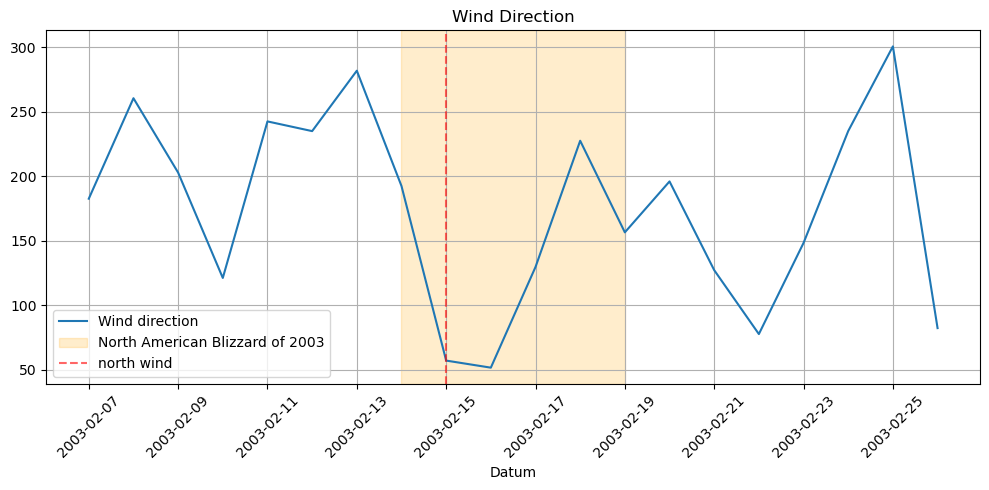

In [82]:
#northwind

fig, ax = plt.subplots(figsize=(10,5))

# Liniendiagramm
ax.plot(df_weather_daily["date"], df_weather_daily["wind_direction"], label="Wind direction", color="tab:blue")

# 🔹 Einen Zeitraum hervorheben (z. B. 7.–10. Februar 2003)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="orange", alpha=0.2, label="North American Blizzard of 2003")

# 🔹 Einen einzelnen Tag hervorheben (z. B. 2003-02-15)
ax.axvline(pd.Timestamp("2003-02-15"), color="red", linestyle="--", alpha=0.6, label="north wind")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.title("Wind Direction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


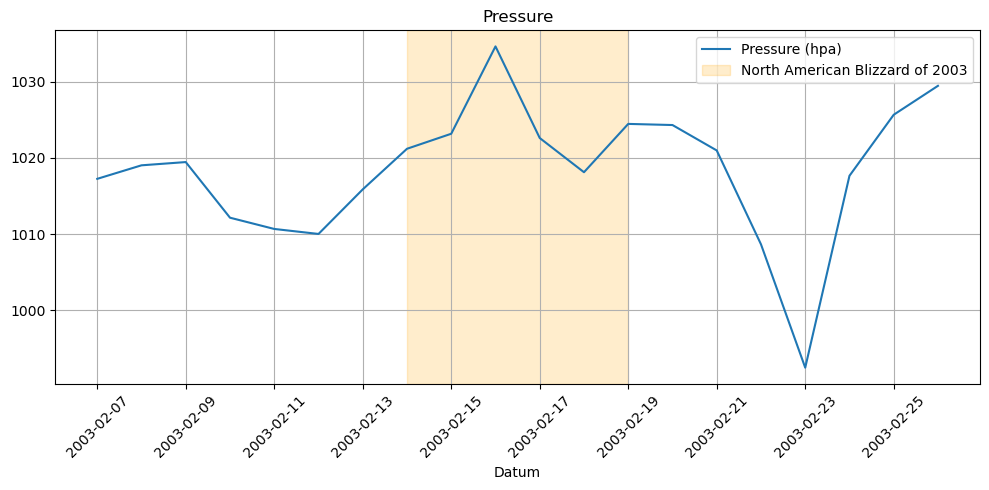

In [71]:
fig, ax = plt.subplots(figsize=(10,5))

# Liniendiagramm
ax.plot(df_weather_daily["date"], df_weather_daily["pressure_hpa"], label="Pressure (hpa)", color="tab:blue")

# 🔹 Einen Zeitraum hervorheben (z. B. 7.–10. Februar 2003)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="orange", alpha=0.2, label="North American Blizzard of 2003")

# 🔹 Einen einzelnen Tag hervorheben (z. B. 2003-02-15)
# ax.axvline(pd.Timestamp("2003-02-15"), color="red", linestyle="--", alpha=0.6, label="kritischer Tag")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.title("Pressure")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


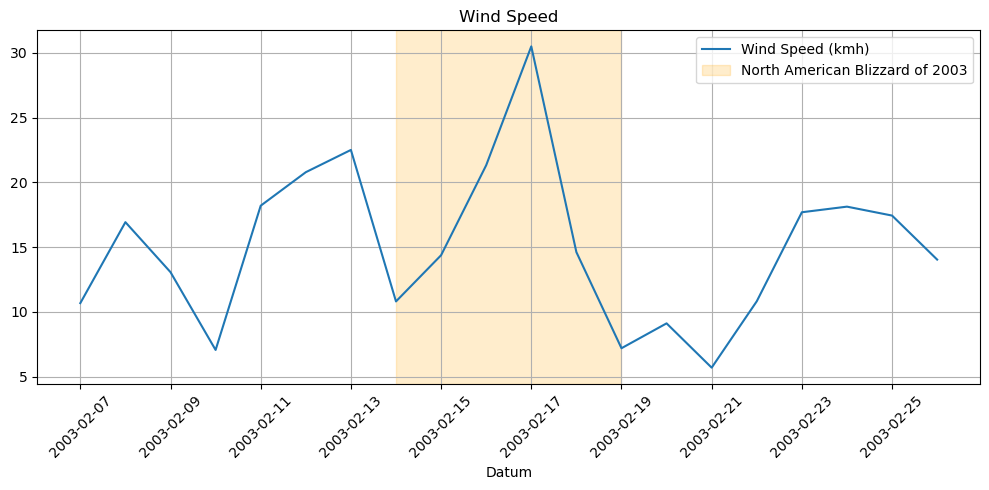

In [ ]:
# adding beaufort scale

fig, ax = plt.subplots(figsize=(10,5))

# Liniendiagramm
ax.plot(df_weather_daily["date"], df_weather_daily["wind_speed_kmh"], label="Wind Speed (kmh)", color="tab:blue")

# 🔹 Einen Zeitraum hervorheben (z. B. 7.–10. Februar 2003)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="orange", alpha=0.2, label="North American Blizzard of 2003")

# 🔹 Einen einzelnen Tag hervorheben (z. B. 2003-02-15)
# ax.axvline(pd.Timestamp("2003-02-15"), color="red", linestyle="--", alpha=0.6, label="kritischer Tag")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.title("Wind Speed")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


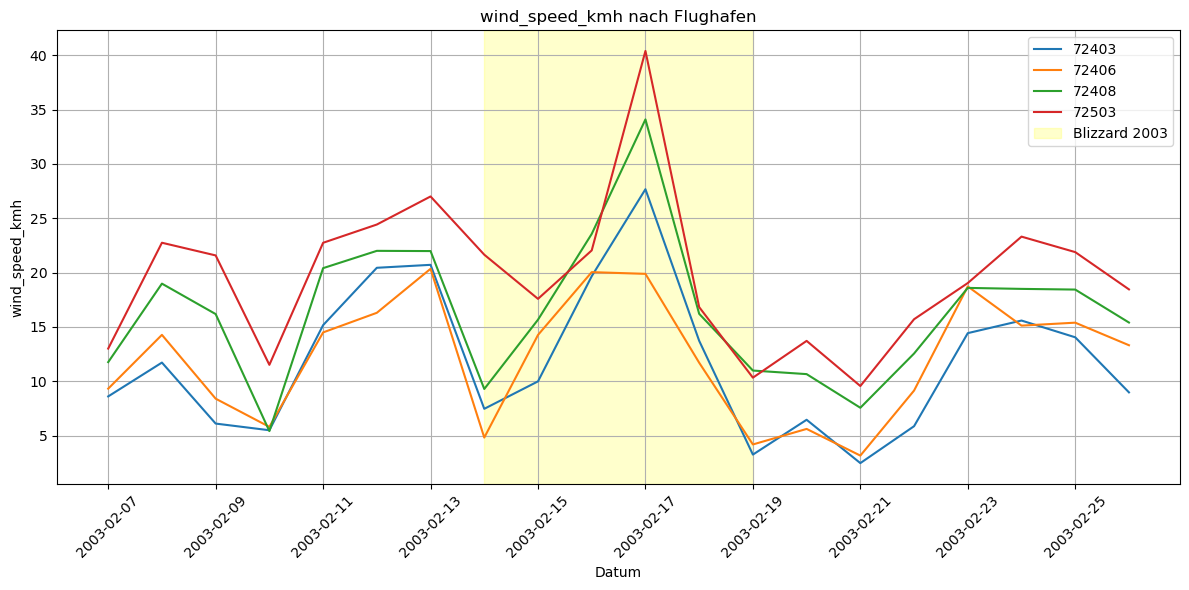

In [80]:
# Beispiel: df_weather_daily hat Spalten: date, station_id, temp_c

fig, ax = plt.subplots(figsize=(12,6))

# Alle Stationen gruppieren und für jede Linie plotten
for station, group in df_weather_daily_by_station.groupby("station_id"):
    ax.plot(group["date"], group["wind_speed_kmh"], label=f"{station}")

# Zeitraum hervorheben (z. B. Blizzard)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="yellow", alpha=0.2, label="Blizzard 2003")

# Optional: einen einzelnen Tag hervorheben
# ax.axvline(pd.Timestamp("2003-02-15"), color="black", linestyle="--", alpha=0.6, label="kritischer Tag")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.ylabel("wind_speed_kmh")
plt.title("wind_speed_kmh nach Flughafen")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

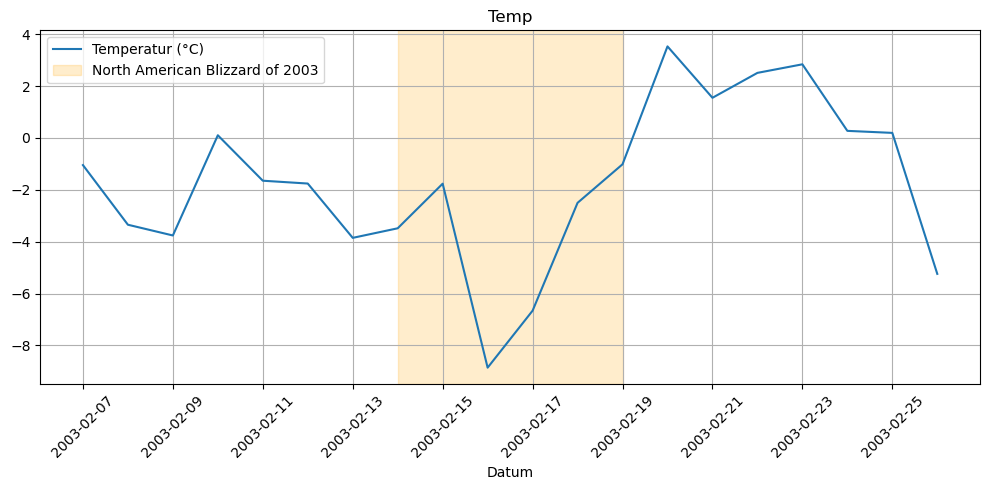

In [64]:
fig, ax = plt.subplots(figsize=(10,5))

# Liniendiagramm
ax.plot(df_weather_daily["date"], df_weather_daily["temp_c"], label="Temperatur (°C)", color="tab:blue")

# 🔹 Einen Zeitraum hervorheben (z. B. 7.–10. Februar 2003)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="orange", alpha=0.2, label="North American Blizzard of 2003")

# 🔹 Einen einzelnen Tag hervorheben (z. B. 2003-02-15)
# ax.axvline(pd.Timestamp("2003-02-15"), color="red", linestyle="--", alpha=0.6, label="kritischer Tag")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.title("Temp")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


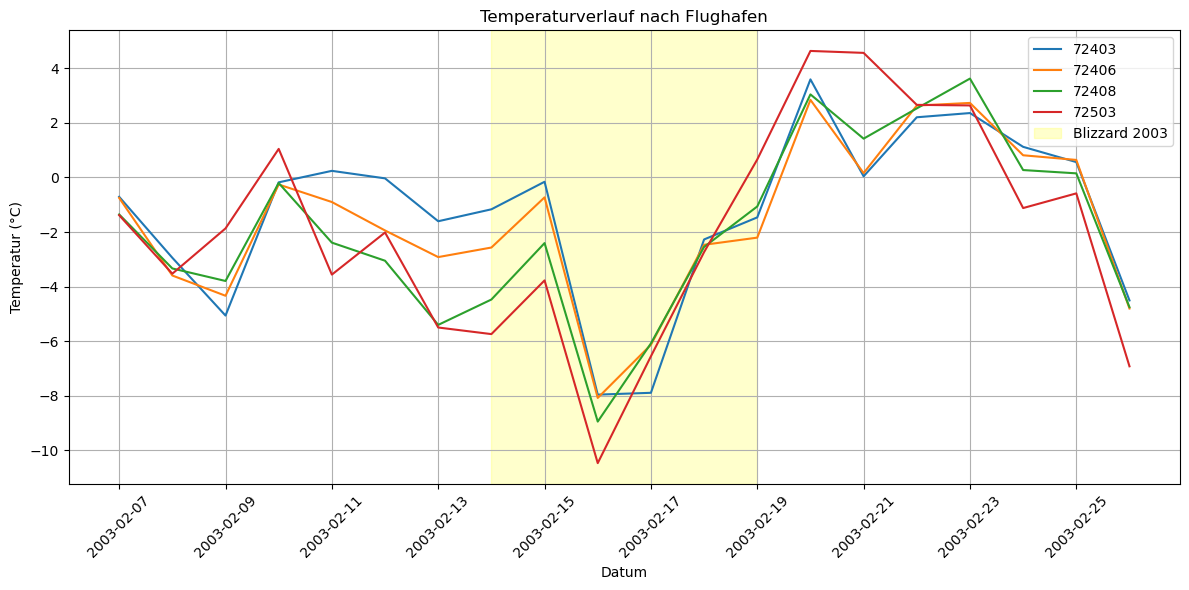

In [79]:
# Beispiel: df_weather_daily hat Spalten: date, station_id, temp_c

fig, ax = plt.subplots(figsize=(12,6))

# Alle Stationen gruppieren und für jede Linie plotten
for station, group in df_weather_daily_by_station.groupby("station_id"):
    ax.plot(group["date"], group["temp_c"], label=f"{station}")

# Zeitraum hervorheben (z. B. Blizzard)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="yellow", alpha=0.2, label="Blizzard 2003")

# Optional: einen einzelnen Tag hervorheben
# ax.axvline(pd.Timestamp("2003-02-15"), color="black", linestyle="--", alpha=0.6, label="kritischer Tag")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.title("Temperaturverlauf nach Flughafen")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Not to use

In [ ]:
df_weather_daily.plot(
    x="date",            # X-Achse
    y="temp_c",          # Y-Achse
    kind="line",         # Liniendiagramm
    figsize=(10, 5),     # Größe
    title="Temperaturverlauf über die Zeit"
)

plt.xlabel("Datum")
plt.ylabel("Temperatur (°C)")
plt.grid(True)
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

# Liniendiagramm
ax.plot(df_weather_daily["date"], df_weather_daily["dewpoint_c"], label="Dewpoint (°C)", color="tab:blue")

# 🔹 Einen Zeitraum hervorheben (z. B. 7.–10. Februar 2003)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="orange", alpha=0.2, label="North American Blizzard of 2003")

# 🔹 Einen einzelnen Tag hervorheben (z. B. 2003-02-15)
# ax.axvline(pd.Timestamp("2003-02-15"), color="red", linestyle="--", alpha=0.6, label="kritischer Tag")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.title("Dewpoint")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

# Liniendiagramm
ax.plot(df_weather_daily["date"], df_weather_daily["humidity_perc"], label="Humidity (%)", color="tab:blue")

# 🔹 Einen Zeitraum hervorheben (z. B. 7.–10. Februar 2003)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="orange", alpha=0.2, label="North American Blizzard of 2003")

# 🔹 Einen einzelnen Tag hervorheben (z. B. 2003-02-15)
# ax.axvline(pd.Timestamp("2003-02-15"), color="red", linestyle="--", alpha=0.6, label="kritischer Tag")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.title("Humidity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(10,5))

# Liniendiagramm
ax.plot(df_weather_daily["date"], df_weather_daily["precipitation_mm"], label="Precipation (mm)", color="tab:blue")

# 🔹 Einen Zeitraum hervorheben (z. B. 7.–10. Februar 2003)
ax.axvspan(pd.Timestamp("2003-02-14"), pd.Timestamp("2003-02-19"),
           color="orange", alpha=0.2, label="North American Blizzard of 2003")

# 🔹 Einen einzelnen Tag hervorheben (z. B. 2003-02-15)
# ax.axvline(pd.Timestamp("2003-02-15"), color="red", linestyle="--", alpha=0.6, label="kritischer Tag")

# Achsen & Stil
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.xticks(rotation=45)
plt.xlabel("Datum")
plt.title("Precipation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
